# 01 · Input Representation

Converts the noisy/clean pairs from `data/mixed/` into model inputs and checks that the conversion is correct.

**Run first** (from the repo root): `python scripts/build_features.py` — it writes everything under `data/processed/` (git-ignored).

| Setting | Value |
|---|---|
| Sample rate | 16 kHz (resampled from 48 kHz) |
| STFT | 512-sample Hann window (32 ms), hop 256 (16 ms) → 257 frequency bins |
| Segment | 2 s = 32 000 samples = 126 frames, zero-padded at the end |
| Split | by speaker: val = reader 08897, test = reader 04408, train = the other 7 |

Each `{split}.npz` holds both representations, so the team can try either:

- **Raw waveform**: `noisy_wav`, `clean_wav` → `(segments, 32000)`
- **Spectrogram**: `noisy_mag`, `clean_mag` → `(segments, 257, 126)`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))

import features as F

FEATURES = ROOT / "data" / "processed" / "features"

train = np.load(FEATURES / "train.npz")
test = np.load(FEATURES / "test.npz")
stats = np.load(FEATURES / "norm_stats.npz")

for key in train.files:
    print(f"{key:<13} {str(train[key].shape):<20} {train[key].dtype}")

noisy_wav     (1292, 32000)        float32


clean_wav     (1292, 32000)        float32


noisy_mag     (1292, 257, 126)     float32


clean_mag     (1292, 257, 126)     float32
frame_mask    (1292, 126)          bool
valid_length  (1292,)              int64
start         (1292,)              int64
mixed_file    (1292,)              <U14


## 1 · The split

The 646 clean clips come from only **9 readers**, so whole readers are held out. Otherwise the model would be tested on voices it trained on.

3 mixtures are excluded because their noise file is completely silent (the mixture is just clean speech).

In [2]:
splits = pd.read_csv(ROOT / "data" / "splits.csv")

print(splits["excluded"].value_counts(), "\n")

used = splits[splits["excluded"].isna()]

display(pd.crosstab(used["split"], used["noise_category"], margins=True))
display(pd.crosstab(used["split"], used["target_snr_db"], margins=True))

excluded
silent noise file    3
Name: count, dtype: int64 



noise_category,copy-machine,door,squeakyChair,typing,All
split,,,,,
test,2,34,5,19,60
train,11,225,72,225,533
val,2,22,3,23,50
All,15,281,80,267,643


target_snr_db,-5,0,5,10,15,20,All
split,,,,,,,
test,9,7,7,6,19,12,60
train,93,90,90,92,79,89,533
val,7,10,7,11,8,7,50
All,109,107,104,109,106,108,643


## 2 · Clean target level fix

`create_mixtures.py` scales speech **and** noise down together when a mixture would clip, but the clean file on disk keeps its original level. 174 clips (mostly −5 and 0 dB) were affected. `build_features.py` estimates that gain by least squares and applies it to the clean target, so `noisy = clean + noise` holds exactly in the saved data.

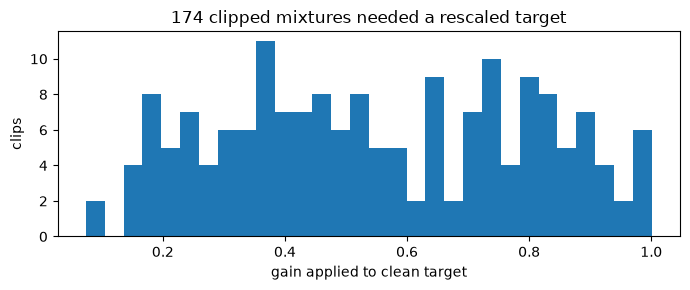

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))

rescaled = splits[splits["clean_gain"] != 1.0]

ax.hist(rescaled["clean_gain"], bins=30)
ax.set_xlabel("gain applied to clean target")
ax.set_ylabel("clips")
ax.set_title(f"{len(rescaled)} clipped mixtures needed a rescaled target")
plt.tight_layout()

## 3 · One example: waveform and spectrograms

mixed_0021.wav | typing | -5 dB


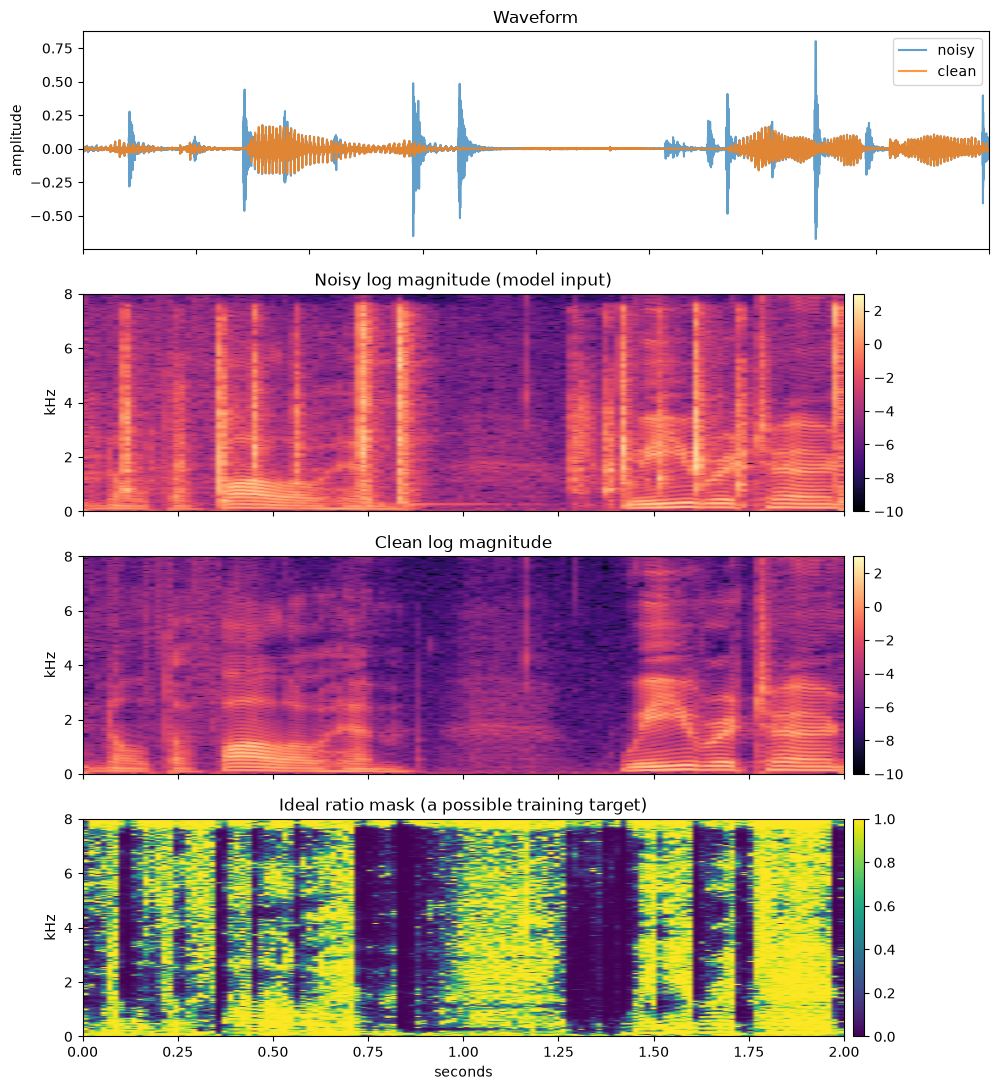

In [4]:
# First test segment with heavy noise and no padding
i = int(np.argmax(
    (test["valid_length"] == F.SEGMENT_SAMPLES)
    & np.isin(
        test["mixed_file"],
        used.loc[used["target_snr_db"] <= 0, "mixed_file"]
    )
))

name = test["mixed_file"][i]
row = used.set_index("mixed_file").loc[name]
print(name, "|", row["noise_category"], "|", row["target_snr_db"], "dB")

noisy_wav, clean_wav = test["noisy_wav"][i], test["clean_wav"][i]
noisy_mag, clean_mag = test["noisy_mag"][i], test["clean_mag"][i]
mask = F.ideal_ratio_mask(clean_mag, noisy_mag)

t = np.arange(F.SEGMENT_SAMPLES) / F.TARGET_SR
extent = [0, F.SEGMENT_SECONDS, 0, F.TARGET_SR / 2000]

fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)

axes[0].plot(t, noisy_wav, label="noisy", alpha=0.7)
axes[0].plot(t, clean_wav, label="clean", alpha=0.8)
axes[0].legend(loc="upper right")
axes[0].set_ylabel("amplitude")
axes[0].set_title("Waveform")

for ax, mag, title in [
    (axes[1], noisy_mag, "Noisy log magnitude (model input)"),
    (axes[2], clean_mag, "Clean log magnitude"),
]:
    image = ax.imshow(
        F.log_magnitude(mag), origin="lower", aspect="auto",
        extent=extent, vmin=-10, vmax=3, cmap="magma"
    )
    ax.set_title(title)
    ax.set_ylabel("kHz")
    fig.colorbar(image, ax=ax, pad=0.01)

image = axes[3].imshow(
    mask, origin="lower", aspect="auto",
    extent=extent, vmin=0, vmax=1, cmap="viridis"
)
axes[3].set_title("Ideal ratio mask (a possible training target)")
axes[3].set_ylabel("kHz")
axes[3].set_xlabel("seconds")
fig.colorbar(image, ax=axes[3], pad=0.01)

plt.tight_layout()

In [5]:
print("Noisy"); display(Audio(noisy_wav, rate=F.TARGET_SR))
print("Clean"); display(Audio(clean_wav, rate=F.TARGET_SR))

Noisy


Clean


## 4 · Sanity checks

1. **Round trip**: spectrogram → audio (with the noisy phase) must give back the original waveform.
2. **Oracle mask**: applying the *ideal* mask to the noisy spectrogram shows the best a mask-based model could do with noisy phase. That is the ceiling for this representation.

In [6]:
def snr_db(reference, estimate, lengths):
    values = []
    for r, e, n in zip(reference, estimate, lengths):
        r, e = r[:n], e[:n]
        values.append(10 * np.log10(np.sum(r ** 2) / np.sum((r - e) ** 2)))
    return np.array(values)


noisy_mag, noisy_phase = F.magnitude_phase(test["noisy_wav"])

round_trip = F.reconstruct(noisy_mag, noisy_phase, F.SEGMENT_SAMPLES)
print(f"Round-trip max error: {np.abs(round_trip - test['noisy_wav']).max():.2e}")

mask = F.ideal_ratio_mask(test["clean_mag"], noisy_mag)
oracle = F.reconstruct(mask * noisy_mag, noisy_phase, F.SEGMENT_SAMPLES)

lengths = test["valid_length"]
before = snr_db(test["clean_wav"], test["noisy_wav"], lengths)
after = snr_db(test["clean_wav"], oracle, lengths)

print(f"Test SNR, noisy input:      {before.mean():6.2f} dB")
print(f"Test SNR, oracle IRM:       {after.mean():6.2f} dB  (upper bound for a mask model)")

Round-trip max error: 1.79e-07


Test SNR, noisy input:       10.09 dB
Test SNR, oracle IRM:        20.34 dB  (upper bound for a mask model)


## 5 · Normalization

The network input is `normalize(log_magnitude(noisy_mag))` using per-frequency mean/std computed on **train only** (padding frames excluded). Val and test reuse the train stats.

Normalized train input: mean 0.000, std 1.000


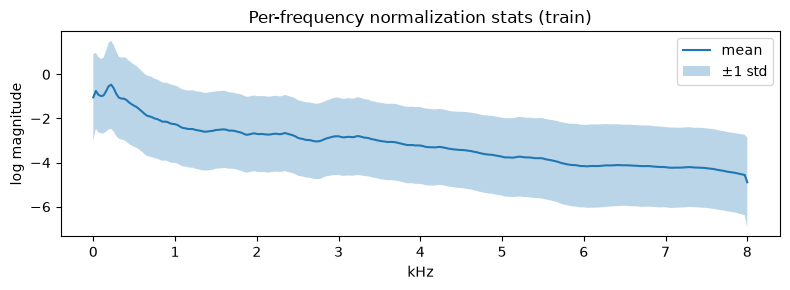

In [7]:
x = F.normalize(F.log_magnitude(train["noisy_mag"]), stats["mean"], stats["std"])
real = np.transpose(x, (1, 0, 2))[:, train["frame_mask"]]

print(f"Normalized train input: mean {real.mean():.3f}, std {real.std():.3f}")

freqs = np.linspace(0, F.TARGET_SR / 2000, F.N_FREQ)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(freqs, stats["mean"], label="mean")
ax.fill_between(freqs, stats["mean"] - stats["std"], stats["mean"] + stats["std"], alpha=0.3, label="±1 std")
ax.set_xlabel("kHz")
ax.set_ylabel("log magnitude")
ax.set_title("Per-frequency normalization stats (train)")
ax.legend()
plt.tight_layout()

## 6 · Using the features in a model

```python
data = np.load("data/processed/features/train.npz")
stats = np.load("data/processed/features/norm_stats.npz")

# Spectrogram model (e.g. CNN / U-Net predicting a mask)
x = F.normalize(F.log_magnitude(data["noisy_mag"]), stats["mean"], stats["std"])  # (N, 257, 126)
y = F.ideal_ratio_mask(data["clean_mag"], data["noisy_mag"])                      # (N, 257, 126)
w = data["frame_mask"]            # ignore padded frames in the loss

# Waveform model (e.g. Conv-TasNet / Wave-U-Net)
x, y = data["noisy_wav"], data["clean_wav"]                                     # (N, 32000)

# Back to audio after prediction
noisy_mag, noisy_phase = F.magnitude_phase(noisy_wav)
denoised = F.reconstruct(predicted_mask * noisy_mag, noisy_phase, length=len(noisy_wav))
```

For PESQ/STOI evaluation, use the full-length clips in `data/processed/wav16k/{noisy,clean}/` rather than the 2 s segments.

**Notes**
- Resampling to 16 kHz drops noise above 8 kHz, so some door/typing mixtures are a bit cleaner than their `target_snr_db` label (up to ~12 dB for a few clips; ~0.5 dB on average).
- Copy-machine noise has only 15 clips (11 in train), so results for that category will be weak.
- Splitting by speaker leaves the test set a little uneven across SNRs (19 of 60 clips are at 15 dB), so report per-SNR results as well as the average.